In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
import spk_feat_cluster_comp_analysis
importlib.reload(spk_feat_cluster_comp_analysis)
from spk_feat_cluster_comp_analysis import (
    compile_experiment_results,
    plot_aggregated_spike_feat,
    plot_temporal_structure,
    analyze_cross_correlations,
    plot_sig_feat_pairs,
    plot_cluster_count_bars,
    stat_test_depth_stratification,
)
import config

CLUSTER_PKL_DIR = config.SPE1_PICKLE_ROOT + '/cluster_pickles/'

In [2]:
df_master = compile_experiment_results(CLUSTER_PKL_DIR)

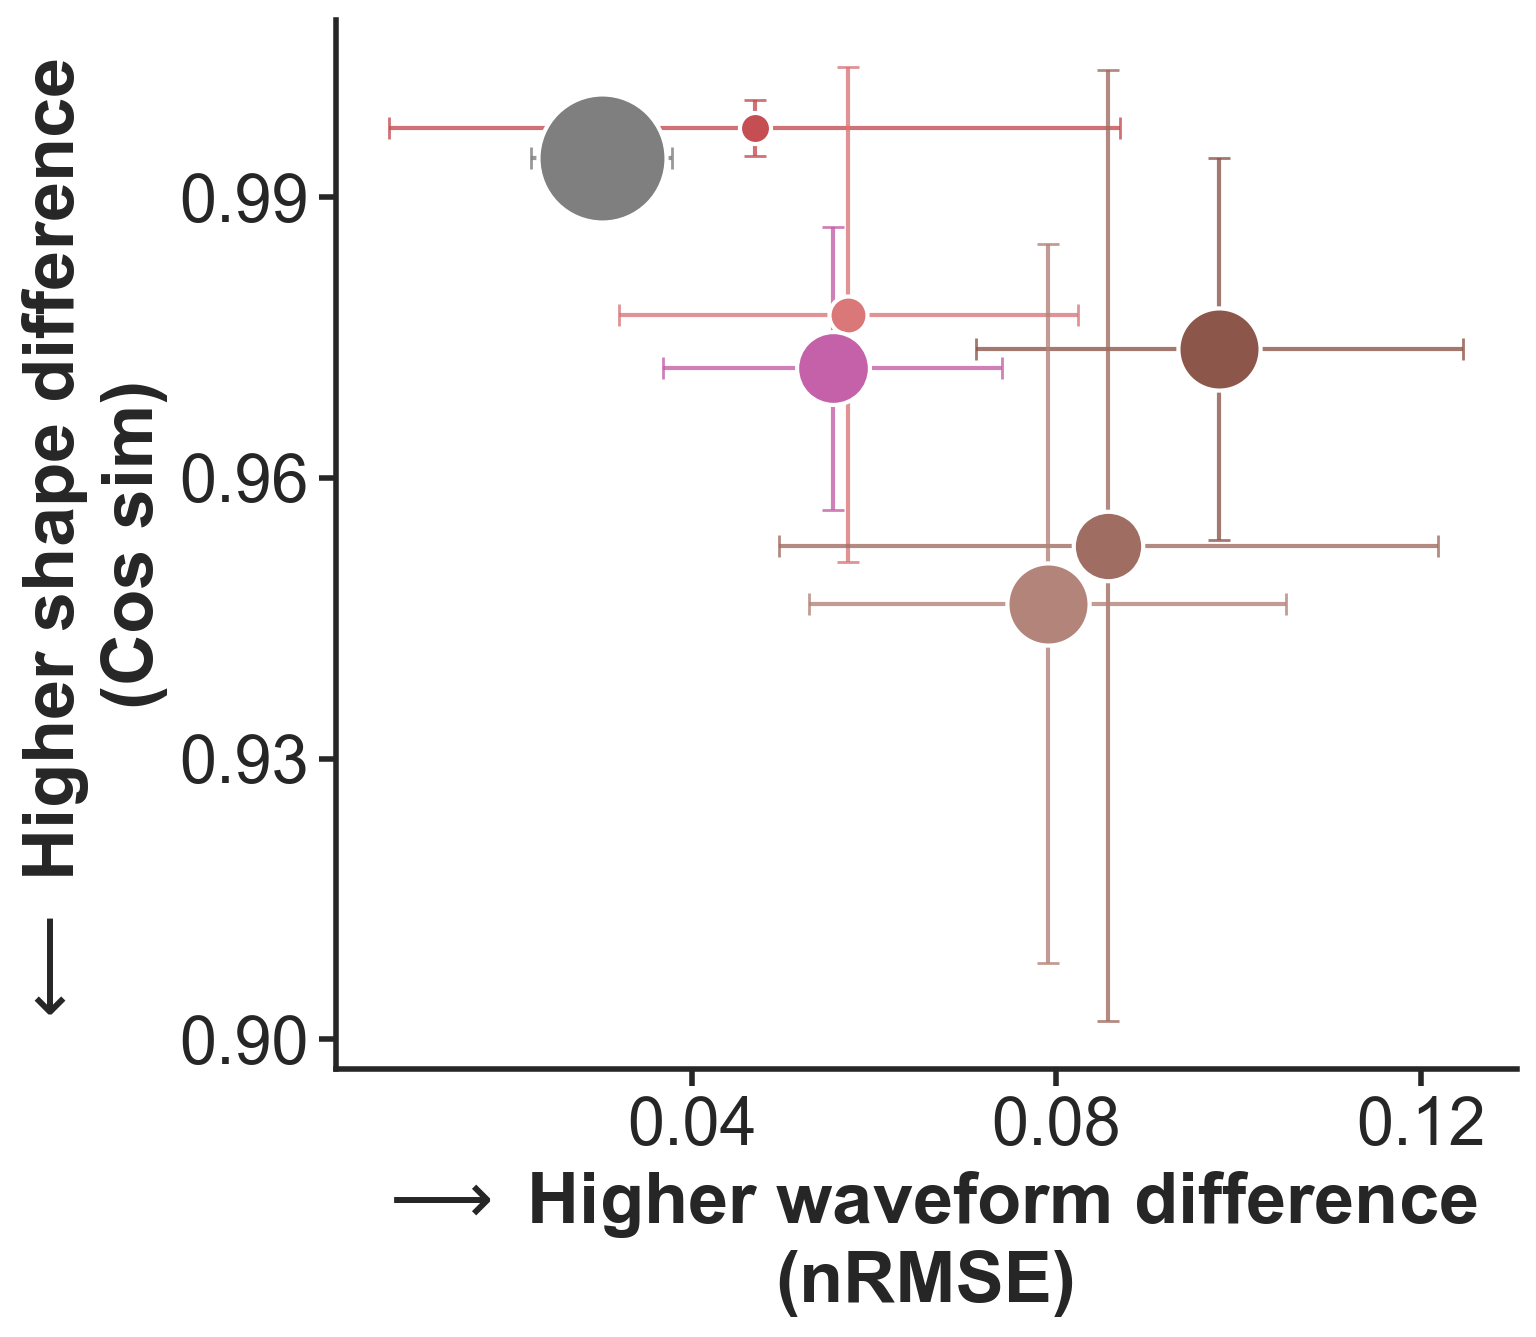

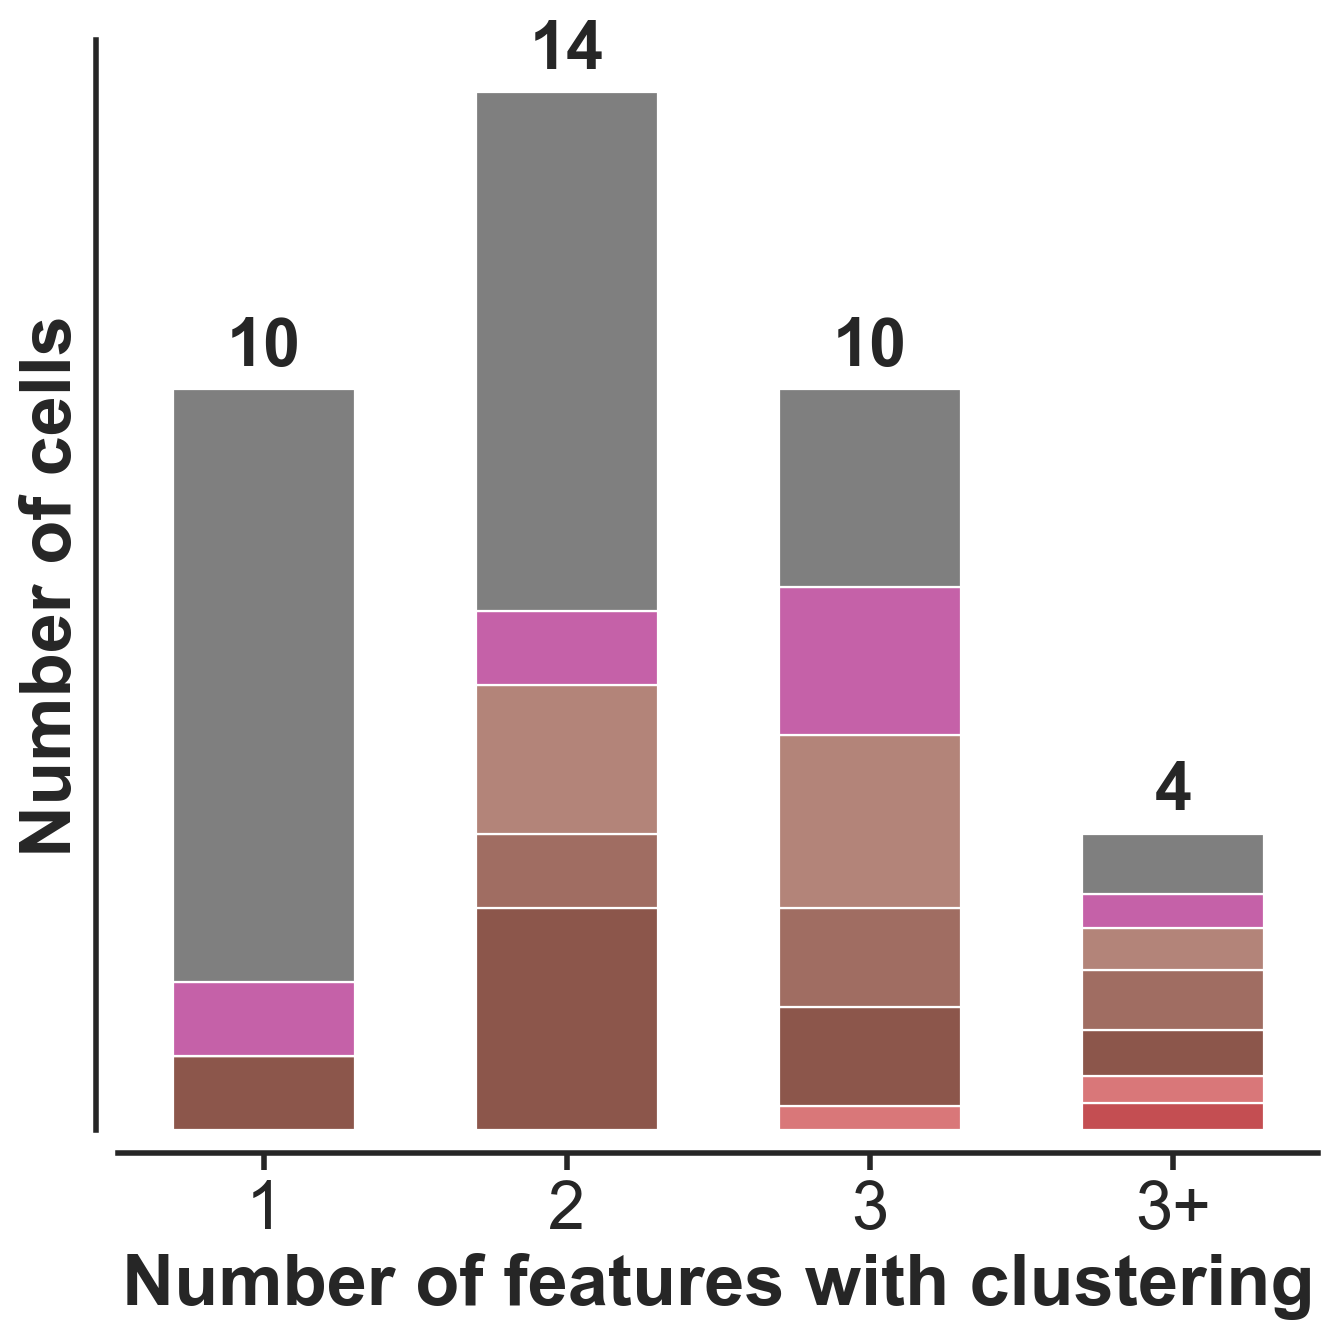

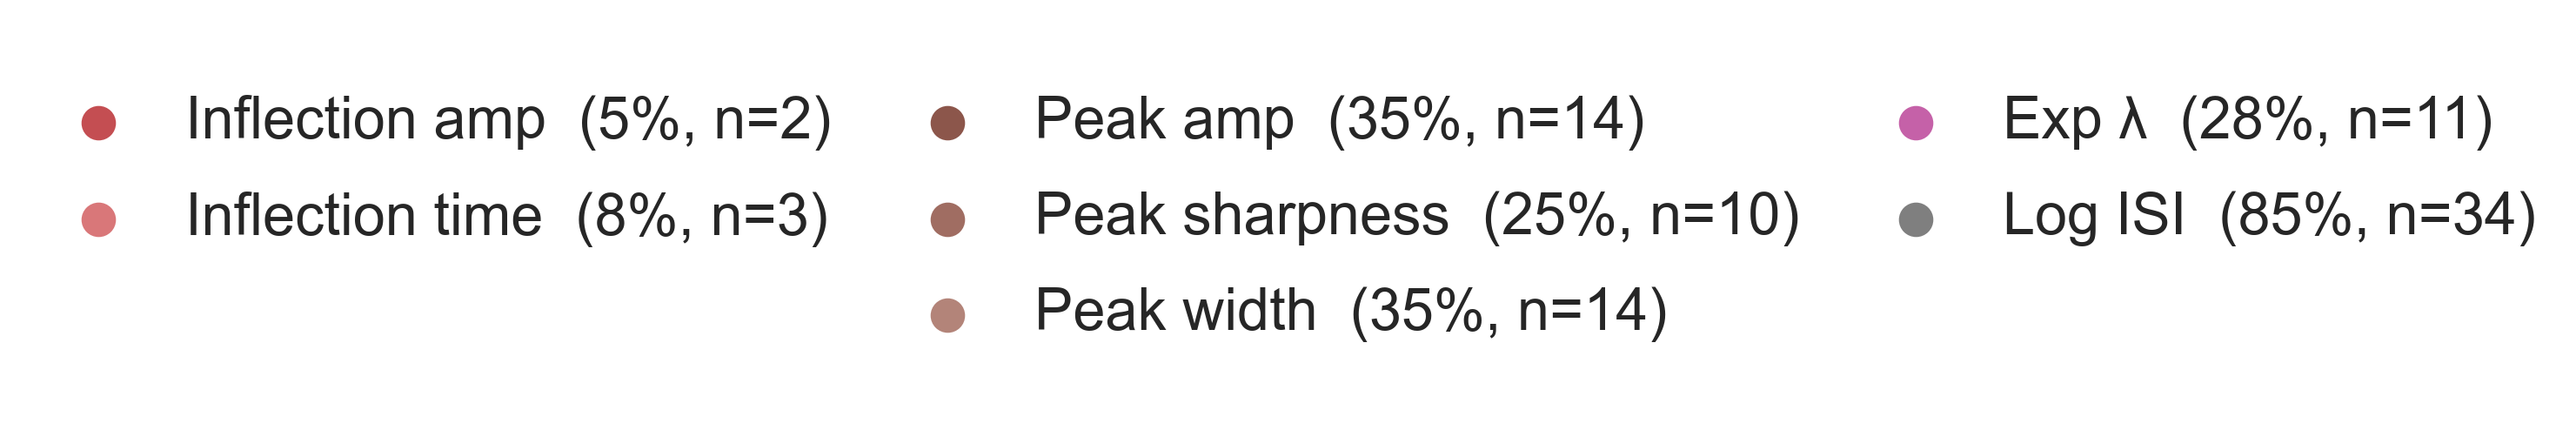

In [3]:
# Panel A: feature prevalence and waveform separation
# Match exclusions from supp_cluster_distributions: skip timing + exp_const + degenerate cells
_SKIP = {'spk_times_ms', 'spk_times_idx', 'exp_const'}
_CELLS_EXCLUDE = {'peak_width': ['c15'], 'inflection_time': ['c7']}

df_wf = df_master[~df_master['spike_feature'].isin(_SKIP)].copy()
for feat, excl in _CELLS_EXCLUDE.items():
    df_wf = df_wf[~((df_wf['spike_feature'] == feat) & (df_wf['cell_id'].isin(excl)))]

plot_aggregated_spike_feat(df_wf, n_total=40)
plt.show()

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2353: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='temporal_rho', y='spike_feature', order=feat_order,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:2355: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_plot, x='temporal_rho', y='spike_feature', order=feat_order,
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysi

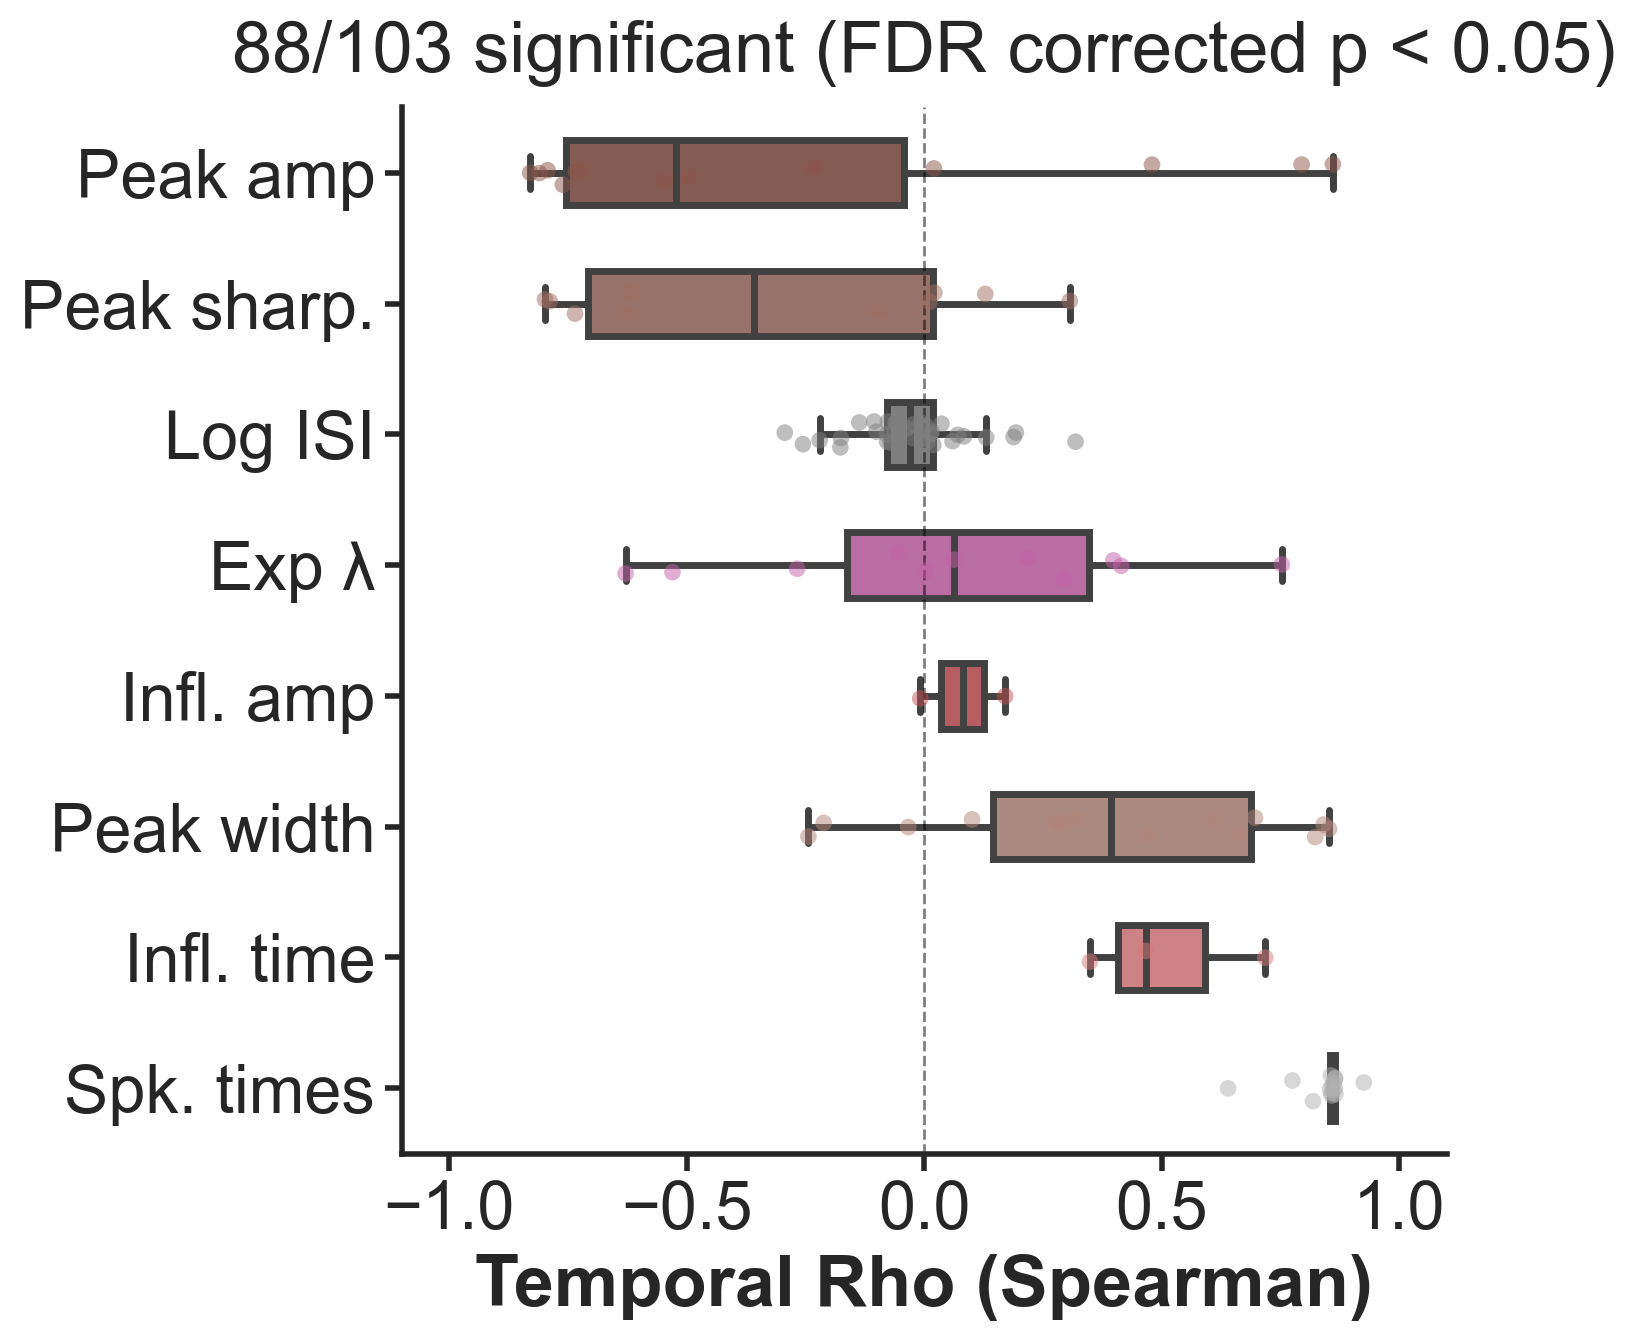


Time dependence summary (FDR corrected p < 0.05):
  Significant: 88 / 103 cell-feature groups (85.4%)
  Mean |rho|: 0.389

Significant groups:
cell_id   spike_feature  temporal_rho temporal_p temporal_q
    c32        peak_amp        -0.829    <0.0001    <0.0001
    c41        peak_amp        -0.810    <0.0001    <0.0001
     c7  peak_sharpness        -0.798    <0.0001    <0.0001
     c1        peak_amp        -0.793    <0.0001    <0.0001
    c32  peak_sharpness        -0.788    <0.0001    <0.0001
    c42        peak_amp        -0.761    <0.0001    <0.0001
    c22  peak_sharpness        -0.735    <0.0001    <0.0001
    c10        peak_amp        -0.733    <0.0001    <0.0001
     c3        peak_amp        -0.724    <0.0001    <0.0001
     c6      exp_lambda        -0.628    <0.0001    <0.0001
     c1  peak_sharpness        -0.628    <0.0001    <0.0001
    c21  peak_sharpness        -0.618    <0.0001    <0.0001
    c44        peak_amp        -0.551    <0.0001    <0.0001
     c1      exp

In [4]:
# Panel B: temporal structure of cluster membership per feature
_SKIP = {'spk_times_idx', 'exp_const'}
_CELLS_EXCLUDE = {'peak_width': ['c15'], 'inflection_time': ['c7']}

df_plot = df_master[~df_master['spike_feature'].isin(_SKIP)].copy()
for feat, excl in _CELLS_EXCLUDE.items():
    df_plot = df_plot[~((df_plot['spike_feature'] == feat) & (df_plot['cell_id'].isin(excl)))]

plot_temporal_structure(df_plot)
plt.show()

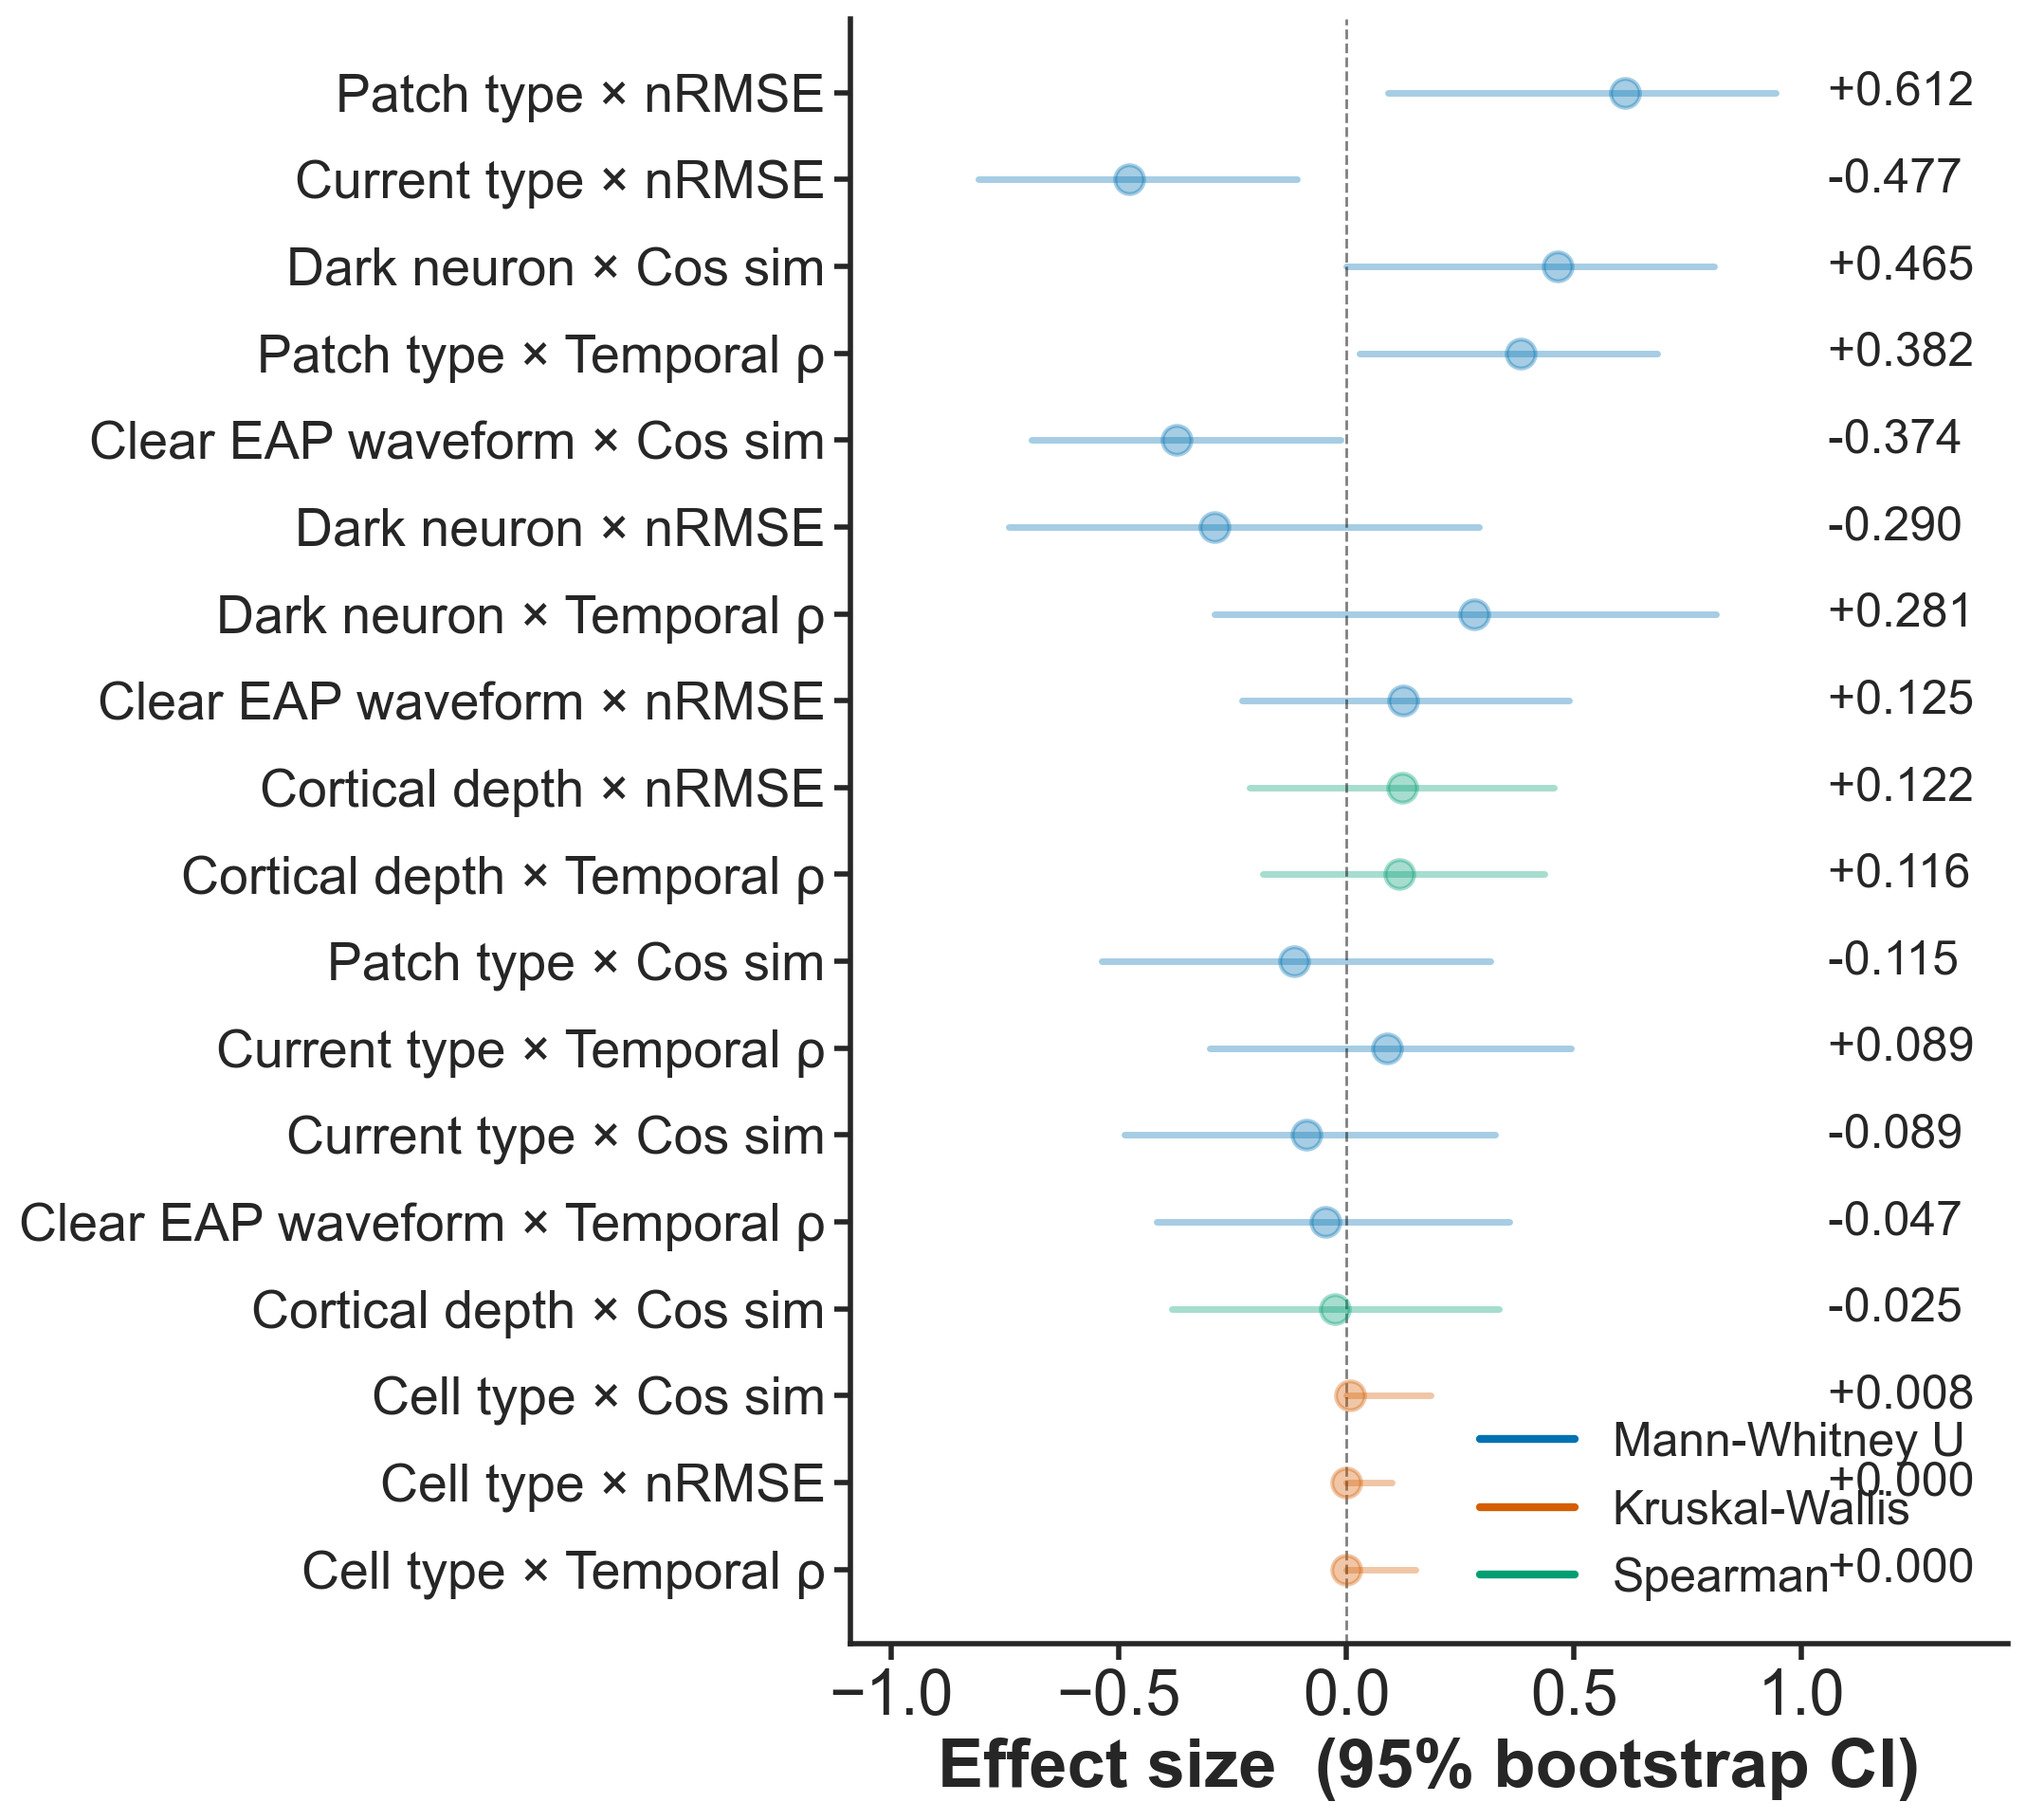


0/18 pairs significant after BH-FDR (α=0.05, n_bootstrap=1000):
No significant pairs to plot.


In [5]:
# Panel C: recording/cell property associations with waveform cluster separation
_SKIP = {'spk_times_ms', 'spk_times_idx', 'exp_const'}
_CELLS_EXCLUDE = {'peak_width': ['c15'], 'inflection_time': ['c7']}

df_wf = df_master[~df_master['spike_feature'].isin(_SKIP)].copy()
for feat, excl in _CELLS_EXCLUDE.items():
    df_wf = df_wf[~((df_wf['spike_feature'] == feat) & (df_wf['cell_id'].isin(excl)))]

sig_meta_clust_feats = analyze_cross_correlations(df_wf)
plot_sig_feat_pairs(df_wf, sig_meta_clust_feats)
plt.show()

**Supplementary Figure X. Characterization of spike waveform cluster properties.**

**(A)** Prevalence of clustering across cells for each spike waveform feature (fraction of cells showing multimodal clustering), with mean nRMSE and cosine similarity between clusters shown as measures of waveform separation.

**(B)** Temporal structure of cluster membership. Spearman ρ between spike index (time within recording) and ordinal cluster label, across all (cell × feature) pairs. High |ρ| indicates that cluster membership is systematically ordered over the recording duration.

**(C)** Associations between recording or cell properties and waveform separation between clusters (nRMSE, cosine similarity, temporal ρ), assessed via Spearman correlation or Mann-Whitney U / Kruskal-Wallis with BH-FDR correction. Tests run at the cell level (metrics averaged across clustering features per cell). Only significant associations shown.

**(D)** Fraction of cells with 2 vs 3 total waveform clusters, broken down by spike waveform feature. Faded bars = 2 clusters; solid bars = 3 clusters.

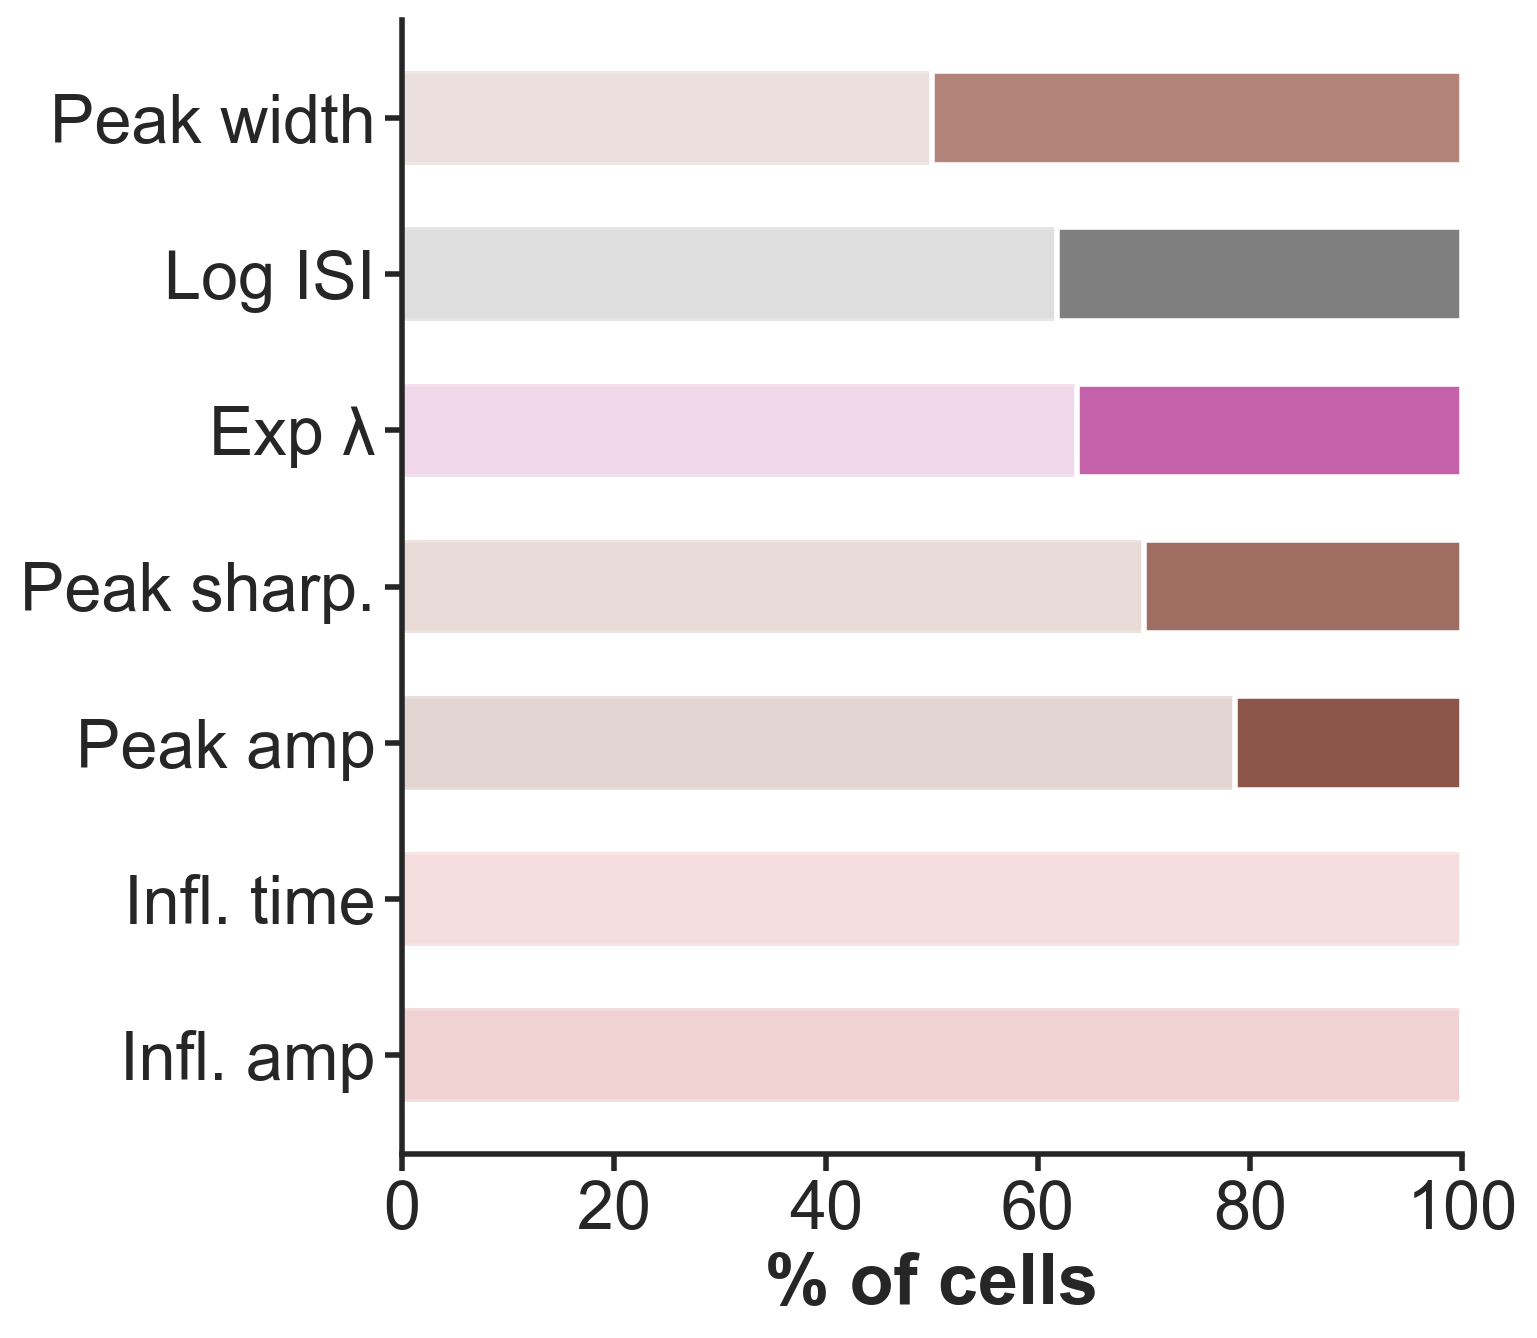

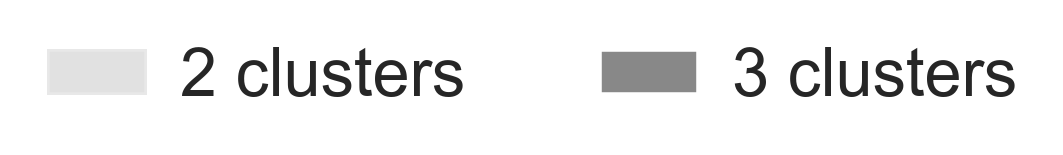

In [6]:
# Panel D: fraction of cells with 2 vs 3 clusters per waveform feature
_SKIP = {'spk_times_ms', 'spk_times_idx', 'exp_const'}
_CELLS_EXCLUDE = {'peak_width': ['c15'], 'inflection_time': ['c7']}

df_wf = df_master[~df_master['spike_feature'].isin(_SKIP)].copy()
for feat, excl in _CELLS_EXCLUDE.items():
    df_wf = df_wf[~((df_wf['spike_feature'] == feat) & (df_wf['cell_id'].isin(excl)))]

plot_cluster_count_bars(df_wf)